In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("akash2sharma/tiny-imagenet")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/akash2sharma/tiny-imagenet


## Phase 1 — Environment Setup

In [47]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q','timm', 'scikit-image', 'gradio'], check=True)

print('All packages ready.')

All packages ready.


In [70]:
import os, math, random, glob, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
import torchvision.transforms.functional as TF

from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU(s) : {torch.cuda.device_count()} × {torch.cuda.get_device_name(0)}')

<function skimage.metrics._structural_similarity.structural_similarity(im1, im2, *, win_size=None, gradient=False, data_range=None, channel_axis=None, gaussian_weights=False, full=False, **kwargs)>

In [49]:
from pathlib import Path

DATA_ROOT = Path('/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200')

TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR   = DATA_ROOT / 'val'

print('Train dir exists:', TRAIN_DIR.exists())
print('Val dir exists:', VAL_DIR.exists())

Train dir exists: True
Val dir exists: True


In [50]:
# ── 1.4  Hyper-parameters ────────────────────────────────────────────────────
IMG_SIZE     = 224
PATCH_SIZE   = 16
NUM_PATCHES  = (IMG_SIZE // PATCH_SIZE) ** 2   # 196
MASK_RATIO   = 0.75
NUM_VISIBLE  = int(NUM_PATCHES * (1 - MASK_RATIO))  # 49
NUM_MASKED   = NUM_PATCHES - NUM_VISIBLE             # 147

# Encoder  (ViT-Base)
ENC_DIM      = 768
ENC_DEPTH    = 12
ENC_HEADS    = 12
ENC_MLP_RATIO= 4

# Decoder  (ViT-Small)
DEC_DIM      = 384
DEC_DEPTH    = 12
DEC_HEADS    = 6
DEC_MLP_RATIO= 4

# Training
BATCH_SIZE   = 32
EPOCHS       = 10
BASE_LR      = 1.5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS= 5
GRAD_CLIP    = 1.0

print(f'Patches total : {NUM_PATCHES}  |  Visible : {NUM_VISIBLE}  |  Masked : {NUM_MASKED}')

Patches total : 196  |  Visible : 49  |  Masked : 147


## Phase 1 (cont.) — Dataset & DataLoader

In [51]:
# ── 1.5  Image transforms ────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

def denormalize(tensor):
    """Invert ImageNet normalisation → [0,1] numpy H×W×3."""
    m = torch.tensor(MEAN, device=tensor.device).view(3,1,1)
    s = torch.tensor(STD,  device=tensor.device).view(3,1,1)
    return (tensor * s + m).clamp(0, 1).cpu().numpy().transpose(1,2,0)

In [52]:
# ── 1.6  TinyImageNet Dataset ────────────────────────────────────────────────
class TinyImageNetDataset(Dataset):
    """
    Supports both the 'train' split (class-sub-folders)
    and the 'val' split (flat images directory).
    """
    def __init__(self, root: Path, split: str = 'train', transform=None):
        self.transform = transform
        self.paths = []

        if split == 'train':
            for cls_dir in sorted(root.iterdir()):
                img_dir = cls_dir / 'images'
                if img_dir.exists():
                    self.paths += list(img_dir.glob('*.JPEG'))
        else:  # val
            img_dir = root / 'images'
            if img_dir.exists():
                self.paths = list(img_dir.glob('*.JPEG'))
            else:
                self.paths = list(root.rglob('*.JPEG'))

        print(f'[{split}] Found {len(self.paths)} images.')

    def __len__(self):  return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


train_ds = TinyImageNetDataset(TRAIN_DIR, 'train', train_transform)
val_ds   = TinyImageNetDataset(VAL_DIR,   'val',   val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, drop_last=False)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}')

[train] Found 100000 images.
[val] Found 10000 images.
Train batches: 3125  |  Val batches: 313


## Phase 2 — Image Patch System

In [53]:
# ── 2.1  Patchify / Unpatchify ───────────────────────────────────────────────
def patchify(imgs: torch.Tensor, patch_size: int = PATCH_SIZE) -> torch.Tensor:
    """
    imgs : (B, 3, H, W)
    return: (B, N, patch_size^2 * 3)   where N = (H/p)*(W/p)
    """
    B, C, H, W = imgs.shape
    p = patch_size
    assert H % p == 0 and W % p == 0
    h, w = H // p, W // p
    x = imgs.reshape(B, C, h, p, w, p)       # B C h p w p
    x = x.permute(0, 2, 4, 3, 5, 1)          # B h w p p C
    x = x.reshape(B, h * w, p * p * C)       # B N (p*p*C)
    return x


def unpatchify(patches: torch.Tensor,
               img_size: int   = IMG_SIZE,
               patch_size: int = PATCH_SIZE) -> torch.Tensor:
    """
    patches : (B, N, p*p*3)
    return  : (B, 3, H, W)
    """
    B, N, _ = patches.shape
    p = patch_size
    h = w = img_size // p
    x = patches.reshape(B, h, w, p, p, 3)    # B h w p p C
    x = x.permute(0, 5, 1, 3, 2, 4)          # B C h p w p
    x = x.reshape(B, 3, h * p, w * p)        # B C H W
    return x


# Quick sanity check
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
patches = patchify(dummy)
recovered = unpatchify(patches)
print('patchify   :', patches.shape)          # (2, 196, 768)
print('unpatchify :', recovered.shape)        # (2, 3, 224, 224)
print('Roundtrip error:', (dummy - recovered).abs().max().item())

patchify   : torch.Size([2, 196, 768])
unpatchify : torch.Size([2, 3, 224, 224])
Roundtrip error: 0.0


In [54]:
# ── 2.2  Random Masking ──────────────────────────────────────────────────────
def random_masking(x: torch.Tensor, mask_ratio: float = MASK_RATIO):
    """
    x : (B, N, D)  — sequence of patch tokens
    Returns:
        x_visible   : (B, N_vis, D)  — only unmasked tokens
        mask        : (B, N)         — 1 = masked, 0 = visible
        ids_restore : (B, N)         — indices to restore original order
    """
    B, N, D = x.shape
    n_keep = int(N * (1 - mask_ratio))

    noise = torch.rand(B, N, device=x.device)            # uniform noise
    ids_shuffle = torch.argsort(noise, dim=1)            # asc → small = keep
    ids_restore = torch.argsort(ids_shuffle, dim=1)

    ids_keep = ids_shuffle[:, :n_keep]                   # (B, n_keep)
    x_visible = torch.gather(x, 1,
                    ids_keep.unsqueeze(-1).expand(-1, -1, D))  # (B, n_keep, D)

    # Build binary mask (1 = masked)
    mask = torch.ones(B, N, device=x.device)
    mask[:, :n_keep] = 0
    mask = torch.gather(mask, 1, ids_restore)            # unshuffle

    return x_visible, mask, ids_restore


# Quick test
dummy_tokens = torch.randn(4, 196, 768)
vis, msk, restore = random_masking(dummy_tokens)
print('Visible tokens :', vis.shape)    # (4, 49, 768)
print('Mask shape     :', msk.shape)    # (4, 196)
print('Mean mask frac :', msk.mean().item())

Visible tokens : torch.Size([4, 49, 768])
Mask shape     : torch.Size([4, 196])
Mean mask frac : 0.75


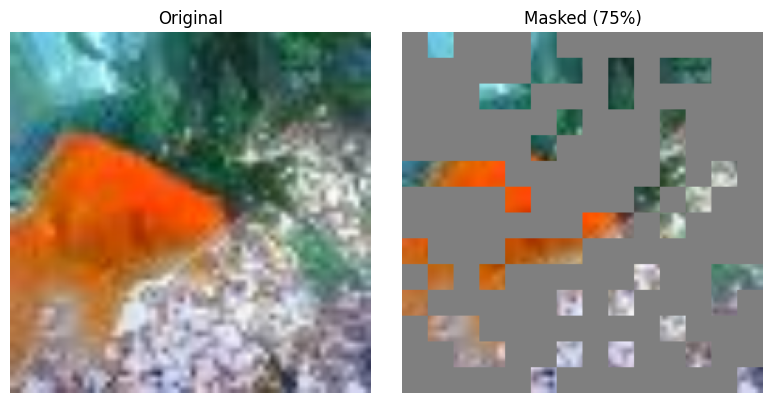

In [55]:
# ── 2.3  Visualise patches & masking ────────────────────────────────────────
def show_masked_image(img_tensor: torch.Tensor, mask: torch.Tensor,
                      patch_size: int = PATCH_SIZE):
    """
    img_tensor : (3, H, W) normalised
    mask       : (N,)  1 = masked
    """
    img_np = denormalize(img_tensor)          # H W C  [0,1]
    H, W, _ = img_np.shape
    p = patch_size
    h = w = H // p
    mask_img = img_np.copy()
    for idx in range(len(mask)):
        if mask[idx] == 1:
            r, c = divmod(idx, w)
            mask_img[r*p:(r+1)*p, c*p:(c+1)*p] = 0.5   # grey-out
    return mask_img


# Grab a sample from train_ds
sample_img = train_ds[0].unsqueeze(0)                   # (1, 3, 224, 224)
patches_sample = patchify(sample_img)                   # (1, 196, 768)
_, mask_sample, _ = random_masking(patches_sample)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(denormalize(sample_img[0]))
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(show_masked_image(sample_img[0], mask_sample[0]))
axes[1].set_title(f'Masked (75%)'); axes[1].axis('off')
plt.tight_layout(); plt.show()

## Phase 3 — MAE Encoder (ViT-Base)

In [56]:
# ── 3.1  Building blocks ─────────────────────────────────────────────────────

class PatchEmbed(nn.Module):
    """Converts raw image pixels → linear patch embeddings."""
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE,
                 in_chans=3, embed_dim=ENC_DIM):
        super().__init__()
        self.patch_size  = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):                   # (B, C, H, W)
        x = self.proj(x)                    # (B, embed_dim, h, w)
        x = x.flatten(2).transpose(1, 2)   # (B, N, embed_dim)
        return x


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(dim, dim * 3, bias=True)
        self.proj      = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        qkv = (self.qkv(x)
                   .reshape(B, N, 3, self.num_heads, self.head_dim)
                   .permute(2, 0, 3, 1, 4))      # 3 B heads N head_dim
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj_drop(self.proj(x))
        return x


class MLP(nn.Module):
    def __init__(self, dim, mlp_ratio=4, drop=0.):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.fc1  = nn.Linear(dim, hidden)
        self.act  = nn.GELU()
        self.fc2  = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        return self.drop(self.fc2(self.act(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4,
                 attn_drop=0., proj_drop=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, attn_drop, proj_drop)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, proj_drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


print('Building blocks defined.')

Building blocks defined.


In [57]:
# ── 3.2  Sinusoidal Positional Embeddings ────────────────────────────────────
def get_2d_sincos_pos_embed(embed_dim: int, grid_size: int,
                             cls_token: bool = False) -> np.ndarray:
    """
    Returns (N, embed_dim) or (1+N, embed_dim) fixed sin/cos embeddings.
    grid_size : number of patches per side
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid   = np.meshgrid(grid_w, grid_h)   # each (grid_size, grid_size)
    grid   = np.stack(grid, axis=0).reshape(2, -1)   # (2, N)

    assert embed_dim % 4 == 0
    half  = embed_dim // 4
    omega = 1.0 / (10000 ** (np.arange(half, dtype=np.float32) / half))

    out_h = np.outer(grid[0], omega)   # (N, half)
    out_w = np.outer(grid[1], omega)
    emb   = np.concatenate([np.sin(out_h), np.cos(out_h),
                             np.sin(out_w), np.cos(out_w)], axis=1)  # (N, D)
    if cls_token:
        emb = np.concatenate([np.zeros((1, embed_dim)), emb], axis=0)
    return emb


print('Positional embedding helper defined.')

Positional embedding helper defined.


In [58]:
# ── 3.3  MAE Encoder ─────────────────────────────────────────────────────────
class MAEEncoder(nn.Module):
    """
    ViT-Base encoder.
    Accepts ONLY visible patches (no mask tokens).
    """
    def __init__(self,
                 img_size    = IMG_SIZE,
                 patch_size  = PATCH_SIZE,
                 embed_dim   = ENC_DIM,
                 depth       = ENC_DEPTH,
                 num_heads   = ENC_HEADS,
                 mlp_ratio   = ENC_MLP_RATIO,
                 mask_ratio  = MASK_RATIO):
        super().__init__()
        self.mask_ratio   = mask_ratio
        self.patch_embed  = PatchEmbed(img_size, patch_size, 3, embed_dim)
        num_patches       = self.patch_embed.num_patches

        # CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Fixed sinusoidal positional embeddings (not learned)
        grid = img_size // patch_size
        pos_embed = get_2d_sincos_pos_embed(embed_dim, grid, cls_token=True)
        self.register_buffer('pos_embed',
                             torch.from_numpy(pos_embed).float().unsqueeze(0))  # (1,1+N,D)

        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, imgs, mask_ratio=None):
        """
        imgs : (B, 3, H, W)
        Returns:
            latent     : (B, n_visible+1, D)  — CLS + visible tokens
            mask       : (B, N)
            ids_restore: (B, N)
        """
        if mask_ratio is None:
            mask_ratio = self.mask_ratio

        # 1. Patch embedding
        x = self.patch_embed(imgs)                    # (B, N, D)

        # 2. Add positional embeddings to all patches before masking
        x = x + self.pos_embed[:, 1:, :]             # skip CLS pos

        # 3. Random masking — keep only visible
        x, mask, ids_restore = random_masking(x, mask_ratio)

        # 4. Prepend CLS token
        cls = self.cls_token.expand(x.shape[0], -1, -1)
        cls = cls + self.pos_embed[:, :1, :]
        x   = torch.cat([cls, x], dim=1)             # (B, 1+n_vis, D)

        # 5. Transformer blocks
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)

        return x, mask, ids_restore


enc = MAEEncoder()
total = sum(p.numel() for p in enc.parameters())
print(f'Encoder parameters: {total/1e6:.1f}M')

Encoder parameters: 85.6M


## Phase 4 — MAE Decoder (ViT-Small)

In [59]:
# ── 4.1  MAE Decoder ─────────────────────────────────────────────────────────
class MAEDecoder(nn.Module):
    """
    ViT-Small decoder.
    Projects encoder latents to decoder dim, inserts learnable mask tokens,
    restores original order, then runs Transformer blocks.
    Final linear head predicts raw pixel values per patch.
    """
    def __init__(self,
                 num_patches  = NUM_PATCHES,
                 patch_size   = PATCH_SIZE,
                 enc_dim      = ENC_DIM,
                 dec_dim      = DEC_DIM,
                 depth        = DEC_DEPTH,
                 num_heads    = DEC_HEADS,
                 mlp_ratio    = DEC_MLP_RATIO):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size  = patch_size
        patch_dim        = patch_size * patch_size * 3

        # Project encoder dim → decoder dim
        self.enc_to_dec = nn.Linear(enc_dim, dec_dim, bias=True)

        # Learnable mask token
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_dim))

        # Fixed positional embeddings for all N patches
        grid      = int(num_patches ** 0.5)
        pos_embed = get_2d_sincos_pos_embed(dec_dim, grid, cls_token=True)
        self.register_buffer('pos_embed',
                             torch.from_numpy(pos_embed).float().unsqueeze(0))

        self.blocks = nn.ModuleList([
            TransformerBlock(dec_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm    = nn.LayerNorm(dec_dim)
        self.head    = nn.Linear(dec_dim, patch_dim, bias=True)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, latent, ids_restore):
        """
        latent      : (B, 1+n_vis, enc_dim)  — CLS + visible encoder output
        ids_restore : (B, N)
        Returns:
            pred : (B, N, patch_dim)   — pixel predictions for all patches
        """
        B = latent.shape[0]

        # 1. Project to decoder dim
        x = self.enc_to_dec(latent)           # (B, 1+n_vis, dec_dim)

        # 2. Expand mask tokens to fill missing positions
        n_vis    = x.shape[1] - 1             # exclude CLS
        n_masked = self.num_patches - n_vis
        mask_tokens = self.mask_token.expand(B, n_masked, -1)   # (B, n_mask, D)

        # 3. Concatenate visible (no CLS) + mask tokens, then unshuffle
        x_no_cls = x[:, 1:, :]               # (B, n_vis, D)
        x_full   = torch.cat([x_no_cls, mask_tokens], dim=1)    # (B, N, D)
        x_full   = torch.gather(x_full, 1,
                       ids_restore.unsqueeze(-1).expand(-1, -1, x_full.shape[-1]))

        # 4. Re-prepend CLS and add pos embeddings
        x_full = torch.cat([x[:, :1, :], x_full], dim=1)        # (B, 1+N, D)
        x_full = x_full + self.pos_embed

        # 5. Decoder blocks
        for blk in self.blocks:
            x_full = blk(x_full)
        x_full = self.norm(x_full)

        # 6. Pixel prediction (drop CLS)
        pred = self.head(x_full[:, 1:, :])   # (B, N, patch_dim)
        return pred


dec = MAEDecoder()
total_dec = sum(p.numel() for p in dec.parameters())
print(f'Decoder parameters: {total_dec/1e6:.1f}M')

Decoder parameters: 21.9M


In [60]:
# ── 4.2  Full MAE model ──────────────────────────────────────────────────────
class MAE(nn.Module):
    def __init__(self, mask_ratio=MASK_RATIO):
        super().__init__()
        self.encoder = MAEEncoder(mask_ratio=mask_ratio)
        self.decoder = MAEDecoder()

    def forward(self, imgs, mask_ratio=None):
        """
        Returns: pred, mask
            pred : (B, N, p*p*3)  — pixel-level reconstruction
            mask : (B, N)         — 1 = was masked
        """
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)
        pred = self.decoder(latent, ids_restore)
        return pred, mask


# Full model test
model = MAE().to(DEVICE)
with torch.no_grad():
    dummy_in = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    pred_out, mask_out = model(dummy_in)
print(f'pred  : {pred_out.shape}')   # (2, 196, 768)
print(f'mask  : {mask_out.shape}')   # (2, 196)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total MAE parameters : {total_params/1e6:.1f}M')

# Multi-GPU support
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs via DataParallel.')
    model = nn.DataParallel(model)

pred  : torch.Size([2, 196, 768])
mask  : torch.Size([2, 196])
Total MAE parameters : 107.5M
Using 2 GPUs via DataParallel.


## Phase 5 — Reconstruction Utilities

In [61]:
# ── 5.1  Masked MSE Loss ─────────────────────────────────────────────────────
def mae_loss(pred: torch.Tensor, target_imgs: torch.Tensor,
             mask: torch.Tensor) -> torch.Tensor:
    """
    pred        : (B, N, p*p*3)
    target_imgs : (B, 3, H, W)
    mask        : (B, N)   1 = masked

    Loss is MSE averaged over masked patches only.
    """
    target = patchify(target_imgs)      # (B, N, p*p*3)
    loss   = (pred - target) ** 2       # (B, N, p*p*3)
    loss   = loss.mean(dim=-1)          # (B, N)  mean over pixels
    loss   = (loss * mask).sum() / (mask.sum() + 1e-6)
    return loss


print('Loss function defined.')

Loss function defined.


In [65]:
# ── 5.2  Reconstruction visualisation ───────────────────────────────────────
@torch.no_grad()
def visualize_reconstruction(model, imgs: torch.Tensor,
                              n_samples: int = 5,
                              mask_ratio: float = MASK_RATIO):
    """
    Displays: Masked Input | Reconstruction | Ground Truth
    imgs : (B, 3, H, W) on CPU
    """
    m = model.module if isinstance(model, nn.DataParallel) else model
    m.eval()
    imgs = imgs[:n_samples].to(DEVICE)
    pred, mask = m(imgs, mask_ratio)

    # Reconstruct: paste pred patches into original where masked
    target   = patchify(imgs)                         # (B, N, p*p*3)
    recon    = target.clone()
    recon[mask.bool()] = pred[mask.bool()].float()            # replace masked
    recon_imgs = unpatchify(recon)                    # (B, 3, H, W)

    fig, axes = plt.subplots(n_samples, 3,
                             figsize=(10, 3 * n_samples))
    titles = ['Masked Input', 'Reconstruction', 'Ground Truth']
    for i in range(n_samples):
        masked_vis  = show_masked_image(imgs[i].cpu(), mask[i].cpu())
        recon_vis   = denormalize(recon_imgs[i])
        orig_vis    = denormalize(imgs[i].cpu())
        for j, (vis, title) in enumerate(zip(
                [masked_vis, recon_vis, orig_vis], titles)):
            axes[i][j].imshow(np.clip(vis, 0, 1))
            if i == 0: axes[i][j].set_title(title, fontsize=12)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.savefig('reconstruction_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    m.train()


print('Visualisation helper defined.')

Visualisation helper defined.


## Phase 6 — Training System

In [63]:
# ── 6.1  Optimiser & scheduler ───────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=BASE_LR,
    betas=(0.9, 0.95),
    weight_decay=WEIGHT_DECAY,
)

# Cosine LR with linear warm-up
total_steps   = EPOCHS * len(train_loader)
warmup_steps  = WARMUP_EPOCHS * len(train_loader)

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler()

print('Optimiser, scheduler, scaler ready.')

Optimiser, scheduler, scaler ready.


In [25]:
# ── 6.2  Training loop ───────────────────────────────────────────────────────
from tqdm import tqdm
import time
import json

scaler = torch.cuda.amp.GradScaler()
optimizer.zero_grad()  # clear any stale grads too

train_losses = []
val_losses   = []
CKPT_PATH = 'mae_best.pth'
best_val  = float('inf')

print(f"\n{'='*65}")
print(f"  MAE Training  |  Epochs: {EPOCHS}  |  Device: {DEVICE}")
print(f"{'='*65}\n")

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    epoch_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]",
        leave=False,
        ncols=90,
        colour='cyan',
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]'
    )

    for step, imgs in enumerate(train_bar):
        imgs = imgs.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        with autocast():
            pred, mask = model(imgs)
            loss = mae_loss(pred, imgs, mask)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        epoch_loss += loss.item()

        # Live loss + LR update every step
        lr_now = optimizer.param_groups[0]['lr']
        train_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            avg=f"{epoch_loss / (step + 1):.4f}",
            lr=f"{lr_now:.2e}",
            refresh=False
        )

    train_losses.append(epoch_loss / len(train_loader))

    # ── Validation ───────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0

    val_bar = tqdm(
        val_loader,
        desc=f"Epoch {epoch:02d}/{EPOCHS} [Val]  ",
        leave=False,
        ncols=90,
        colour='green',
        bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]'
    )

    with torch.no_grad():
        for step, imgs in enumerate(val_bar):
            imgs = imgs.to(DEVICE, non_blocking=True)
            with autocast():
                pred, mask = model(imgs)
                loss = mae_loss(pred, imgs, mask)
            val_loss += loss.item()
            val_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                avg=f"{val_loss / (step + 1):.4f}",
                refresh=False
            )

    val_losses.append(val_loss / len(val_loader))
    with open('training_history.json', 'w') as f:
        json.dump({'train': train_losses, 'val': val_losses}, f)

    # ── Checkpoint ───────────────────────────────────────────────────────────
    improved = val_losses[-1] < best_val
    if improved:
        best_val = val_losses[-1]
        m_state = (model.module if isinstance(model, nn.DataParallel)
                   else model).state_dict()
        torch.save(m_state, CKPT_PATH)

    # ── Epoch summary ─────────────────────────────────────────────────────────
    epoch_time = time.time() - epoch_start
    ckpt_tag   = " ✓ saved" if improved else ""
    lr_now     = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train: {train_losses[-1]:.4f} | "
        f"Val: {val_losses[-1]:.4f} | "
        f"Best: {best_val:.4f}{ckpt_tag} | "
        f"LR: {lr_now:.2e} | "
        f"{epoch_time:.1f}s"
    )

print(f"\n{'='*65}")
print(f"  Training complete.  Best val loss: {best_val:.4f}  →  {CKPT_PATH}")
print(f"{'='*65}\n")


  MAE Training  |  Epochs: 10  |  Device: cuda



Epoch 01/10 | Train: 0.5012 | Val: 0.3784 | Best: 0.3784 ✓ saved | LR: 3.87e-05 | 804.1s


Epoch 02/10 | Train: 0.3406 | Val: 0.3105 | Best: 0.3105 ✓ saved | LR: 6.87e-05 | 781.5s


Epoch 03/10 | Train: 0.2976 | Val: 0.2882 | Best: 0.2882 ✓ saved | LR: 9.87e-05 | 781.2s


Epoch 04/10 | Train: 0.2783 | Val: 0.2695 | Best: 0.2695 ✓ saved | LR: 1.29e-04 | 781.1s


...

Epoch 06/10 | Train: 0.2563 | Val: 0.2494 | Best: 0.2494 ✓ saved | LR: 1.49e-04 | 782.6s


Epoch 07/10 | Train: 0.2485 | Val: 0.2425 | Best: 0.2425 ✓ saved | LR: 1.47e-04 | 781.9s


Epoch 08/10 | Train: 0.2422 | Val: 0.2382 | Best: 0.2382 ✓ saved | LR: 1.44e-04 | 781.7s


Epoch 09/10 | Train: 0.2371 | Val: 0.2366 | Best: 0.2366 ✓ saved | LR: 1.39e-04 | 780.9s


Epoch 10/10 | Train: 0.2335 | Val: 0.2312 | Best: 0.2312 ✓ saved | LR: 1.34e-04 | 781.3s

  Training complete.  Best val loss: 0.2312  →  mae_best.pth



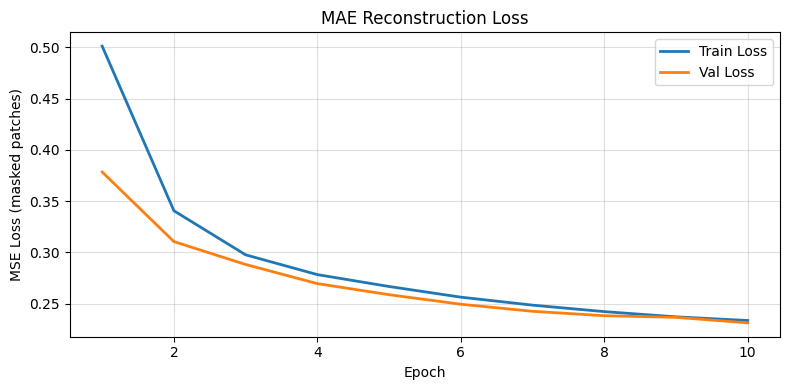

In [10]:
import json
import matplotlib.pyplot as plt

# with open('training_history.json') as f:
#     history = json.load(f)

# train_losses = history['train']
# val_losses   = history['val']
# EPOCHS = len(train_losses)

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', linewidth=2)
plt.plot(range(1, EPOCHS+1), val_losses,   label='Val Loss',   linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (masked patches)')
plt.title('MAE Reconstruction Loss')
plt.legend(); plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

## Evaluation — PSNR & SSIM + Qualitative Samples

In [25]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
CKPT_PATH = 'mae_best.pth'
best_model = MAE().to(DEVICE)
state = torch.load(CKPT_PATH, map_location=DEVICE)
best_model.load_state_dict(state)
best_model.eval()
print('Best model loaded.')

Best model loaded.


In [71]:
# ── Quantitative evaluation ──────────────────────────────────────────────────
@torch.no_grad()
def evaluate_metrics(model, loader, n_batches=10):
    psnr_scores, ssim_scores = [], []
    model.eval()

    for i, imgs in enumerate(loader):
        if i >= n_batches: break
        imgs = imgs.to(DEVICE)

        with autocast():
            pred, mask = model(imgs)

        target   = patchify(imgs)
        recon    = target.clone()
        recon[mask.bool()] = pred[mask.bool()].float()
        recon_imgs = unpatchify(recon)          # (B, 3, H, W)

        for j in range(imgs.size(0)):
            orig = denormalize(imgs[j].cpu())
            rec  = np.clip(denormalize(recon_imgs[j]), 0, 1)

            psnr_scores.append(psnr_fn(orig, rec, data_range=1.0))
            ssim_scores.append(ssim_fn(
                orig, rec, data_range=1.0, channel_axis=2))

    print(f'Evaluated on {len(psnr_scores)} images')
    print(f'  PSNR : {np.mean(psnr_scores):.2f} ± {np.std(psnr_scores):.2f} dB')
    print(f'  SSIM : {np.mean(ssim_scores):.4f} ± {np.std(ssim_scores):.4f}')
    return psnr_scores, ssim_scores


psnr_list, ssim_list = evaluate_metrics(best_model, val_loader)

Evaluated on 320 images
  PSNR : 21.41 ± 2.97 dB
  SSIM : 0.6736 ± 0.1009


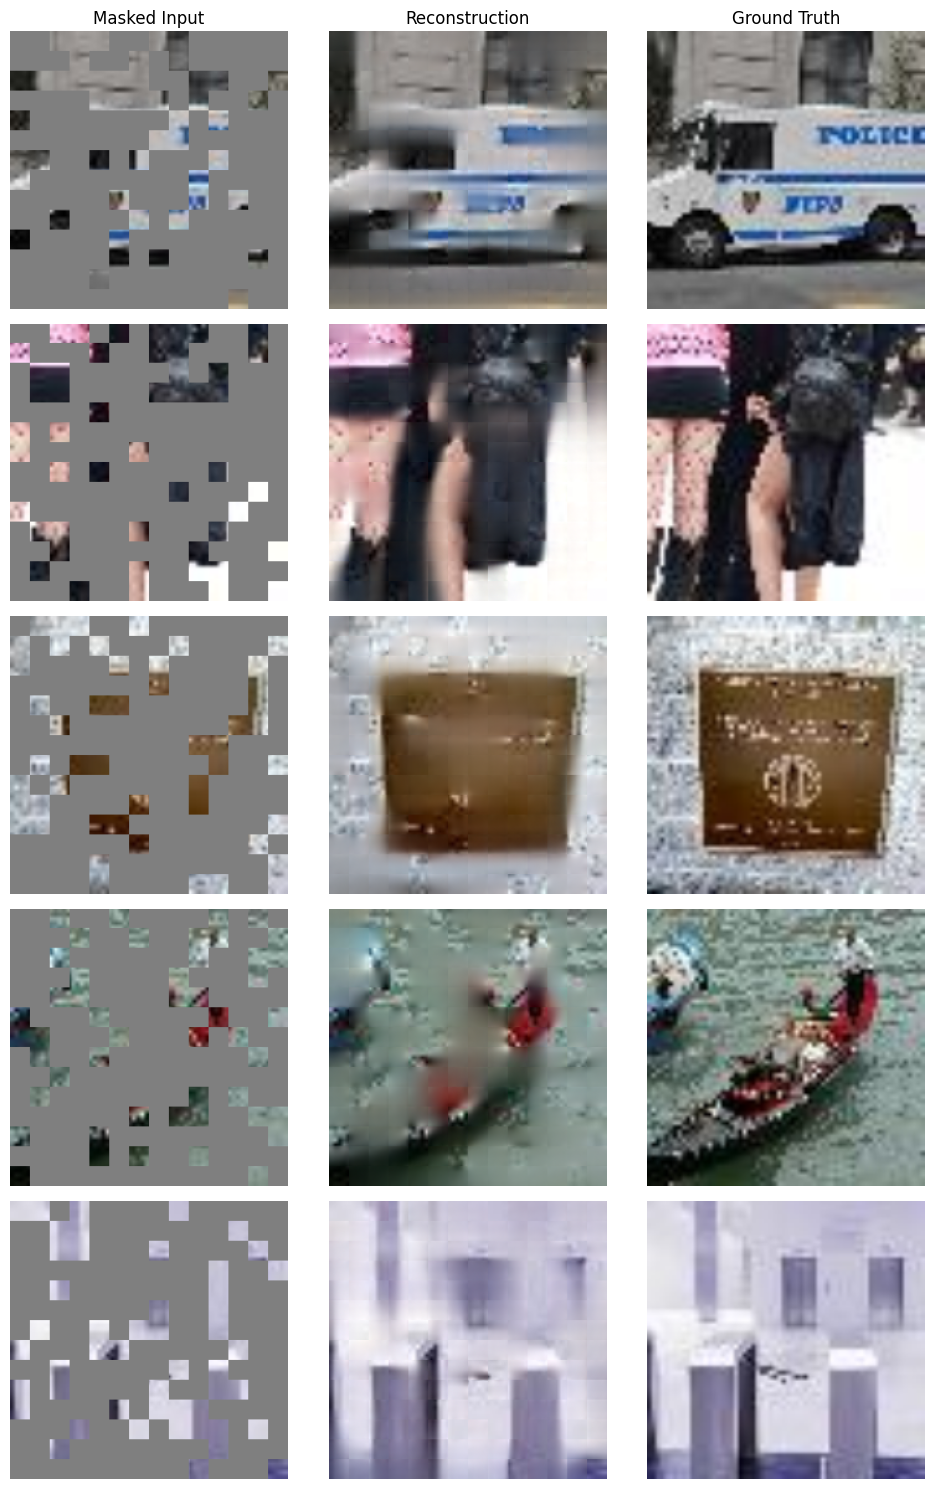

In [72]:
# ── Qualitative samples (≥ 5) ────────────────────────────────────────────────
sample_batch = next(iter(val_loader))
visualize_reconstruction(best_model, sample_batch, n_samples=5)

## App Deployment — Gradio Interface

In [73]:
# ── Gradio App ───────────────────────────────────────────────────────────────
import gradio as gr

def predict(pil_image, mask_ratio_pct):
    """Gradio inference function."""
    mask_ratio = float(mask_ratio_pct) / 100.0

    transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])
    img_tensor = transform(pil_image.convert('RGB')).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred, mask = best_model(img_tensor, mask_ratio)

    # Masked input
    masked_vis = show_masked_image(img_tensor[0].cpu(), mask[0].cpu())

    # Reconstruction
    target       = patchify(img_tensor)
    recon        = target.clone()
    recon[mask.bool()] = pred[mask.bool()]
    recon_img    = np.clip(denormalize(unpatchify(recon)[0]), 0, 1)

    # Original
    orig         = denormalize(img_tensor[0].cpu())

    # Convert to uint8 PIL images
    to_pil = lambda arr: Image.fromarray((arr * 255).astype(np.uint8))
    return to_pil(masked_vis), to_pil(recon_img), to_pil(orig)


with gr.Blocks(title='MAE — Masked Autoencoder') as demo:
    gr.Markdown('# 🎭 Masked Autoencoder (MAE) Demo\n'
                'Upload an image, select masking ratio and see the model reconstruct missing patches.')

    with gr.Row():
        inp_img   = gr.Image(type='pil', label='Upload Image')
        mask_pct  = gr.Slider(10, 90, value=75, step=5,
                              label='Masking Ratio (%)')

    btn = gr.Button('Reconstruct', variant='primary')

    with gr.Row():
        out_masked = gr.Image(label='Masked Input')
        out_recon  = gr.Image(label='Reconstruction')
        out_orig   = gr.Image(label='Ground Truth')

    btn.click(fn=predict,
              inputs=[inp_img, mask_pct],
              outputs=[out_masked, out_recon, out_orig])

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a25a700f0d2318e269.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
